[![Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/giordamaug/decouple_emb_lgbm/blob/main/notebook.ipynb)

## Libraries

In [3]:
import torch
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter(action='ignore')
import numpy as np
import os
import random
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"       # to force BERT determinsm

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # per multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)

## Load dataset

In [4]:
import sys
sys.path.append('.')
from scripts.utils import Settings

dataset = "INA_icd"
if dataset == "INA_orig":
    datafile =  "data/dataset_14_04_26_EN.json"
    target_var = "is_alive?"
    evfields = ['event']
    static_vars = ["gender", "age_group", "base_pathology_area"]
    remove_events = ['followup', 'platelet', 'bmi_change', 'thrombosys']
    no_selection = False
    thresh = 0.3
elif dataset == "INA":
    datafile =  "dataset_14_04_26_EN_final.json"
    static_vars = ["gender", "age_at_splenectomy", "base_pathology_area"]
    target_var = "is_alive?"
    evfields = ['event']
    remove_events = ['followup', 'platelet', 'bmi_change', 'thrombosys']
    no_selection = False
    thresh = 0.3
elif dataset == "INA_icd":
    datafile =  "data/dataset_14_04_26_EN.json"
    target_var = "is_alive?"
    evfields = ['code_descr']
    static_vars = ["gender", "age_group", "base_pathology_area"]
    remove_events = ['followup', 'platelet', 'bmi_change', 'thrombosys']
    no_selection = False
    thresh = 0.3
elif dataset == "MIMIC":
    datafile = "mimic-iv_asplenic_4133_final.json"
    #datafile = "../SysBiology_paper/mimic-iv_asplenic_1368.json"
    static_vars = ["gender", "age_at_splenectomy", "base_pathology_area"]
    target_var = "is_alive?"
    evfields = ['event']
    remove_events = ['drug'] #, 'therapy']
    no_selection = True
    thresh = 0.3
elif dataset == "eiCU":
    datafile = "eicu_asplenia_patients_synthetic_dates.json"
    #datafile = "../SysBiology_paper/mimic-iv_asplenic_1368.json"
    static_vars = ["gender", "age_group", "ethnicity", "primary_disease_category"]
    target_var = "is_alive?"
    evfields = ['event']
    remove_events = ['outcome', 'medication'] #, 'therapy']
    no_selection = True
    thresh = 0.3
else:
    raise Exception("dataset not supported!")
args = Settings(datafile = datafile, 
                no_selection=no_selection,
                pathology_field = 'base_pathology_area', #'base_pathology_area', # 'primarys_disease'
                static_vars= static_vars,
                target_var = target_var,
                pathologies={'Asplenic Syndromes' : 'AS', 
                            'Autoimmune Hematological Diseases' : 'AIHD', 
                            'Congenital Hemolytic Anemias' : 'CHA', 
                            'Immunodeficiencies' : 'IM', 
                            'NTDT - (Non Transfusion Dependent Thalassemia - Intermediate Thalassemia)' : 'NTDT', 
                            'Non-Hemato-Oncological Causes' : 'NHOC', 
                            'Oncological Diseases' : 'OD', 
                            'SCD - (Sickle Cell Disease, Anemia/Sickle Cell or Sickle Cell Disease)' : 'SCD', 
                            'TDT - (Transfusion Dependent Thalassemia - Thalassemia Major)' : 'TDT'},
                spleen_flags = ['YES', 'NO'],
                selected_spleen_flags = ['YES'],
                methods=['LSTM', 'GRU', 'GRU-D', 'BEHRT', 'Dipole', 'DOME', 'BINARY'],
                evfields = evfields,
                remove_events = remove_events,
                save_events=False,
                enable_plot=True, 
                n_splits=5, 
                num_epochs=10, 
                batch_size = 16, 
                embedding_size=128,
                hidden_size=300)
args.iterated_cv = True
args.iter = 5
args.results_dir = "results_calib"

Loaded 1492 records from data/dataset_14_04_26_EN.json


### Remove patients with specific cause of death

In [5]:
if "cause_of_death" in args.dataset.columns:
    words = ["accident", "trauma", "suicide", "fracture", "malignant", "myeloma"]
    pattern = "|".join(words)
    args.dataset = args.dataset[~args.dataset["cause_of_death"].str.contains(pattern, case=False, na=False)]
    args.selected_patient_ids = args.dataset.index
    print("Patients no:", len(args.selected_patient_ids))

Patients no: 1487


### Remove patients with no events

In [6]:
args.dataset = args.dataset[args.dataset["events"].apply(lambda x: x != [])]
args.selected_patient_ids = args.dataset.index
print("Patients no:", len(args.selected_patient_ids))

Patients no: 1486


## Plot patients distribution

Index(['Congenital Hemolytic Anemias',
       'TDT - (Transfusion Dependent Thalassemia - Thalassemia Major)',
       'NTDT - (Non Transfusion Dependent Thalassemia - Intermediate Thalassemia)',
       'Autoimmune Hematological Diseases',
       'SCD - (Sickle Cell Disease, Anemia/Sickle Cell or Sickle Cell Disease)',
       'Non-Hemato-Oncological Causes', 'Oncological Diseases',
       'Immunodeficiencies', 'Asplenic Syndromes'],
      dtype='object', name='base_pathology_area')


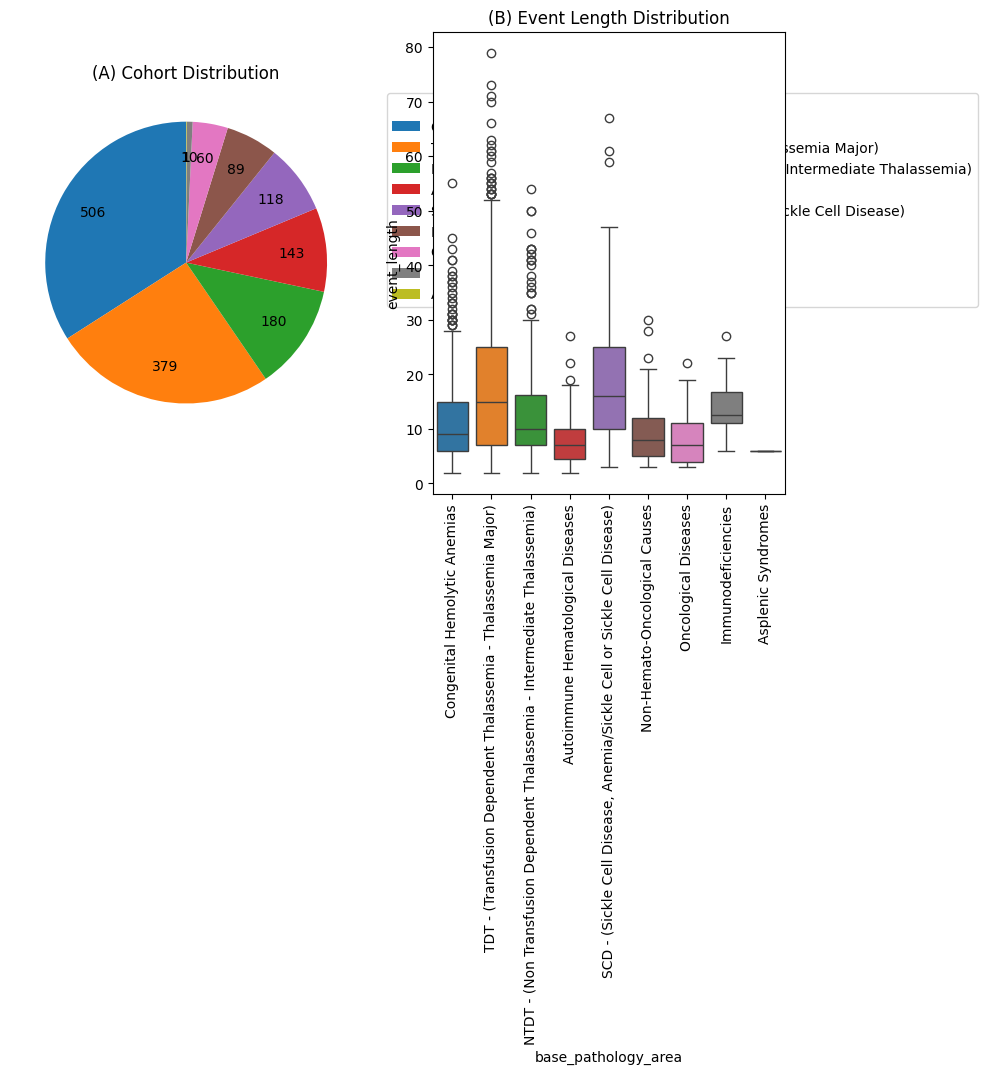

In [7]:
if "base_pathology_area" in args.dataset.columns:
    from scripts.utils import plot_group_distribution_with_event_boxplot
    plot_group_distribution_with_event_boxplot(args.dataset, groupby=args.pathology_field)#, label_desc=args.pathologies)

## Get clinical trajectories

In [8]:
from scripts.utils import count_events_by_type
events_field, date_field, type_field = 'events', 'date', 'type'
event_sequences = { id: [(" ".join([event[field] if isinstance(event[field], str) else "NONE" for field in args.evfields]), 
    event[date_field], event[type_field]) for event in events] for (id,events) in args.dataset[[events_field]].to_dict()[events_field].items()} 

### Remove events by types

n.1486 Patients
Index(['Congenital Hemolytic Anemias',
       'TDT - (Transfusion Dependent Thalassemia - Thalassemia Major)',
       'NTDT - (Non Transfusion Dependent Thalassemia - Intermediate Thalassemia)',
       'Autoimmune Hematological Diseases',
       'SCD - (Sickle Cell Disease, Anemia/Sickle Cell or Sickle Cell Disease)',
       'Non-Hemato-Oncological Causes', 'Oncological Diseases',
       'Immunodeficiencies', 'Asplenic Syndromes'],
      dtype='object', name='base_pathology_area')


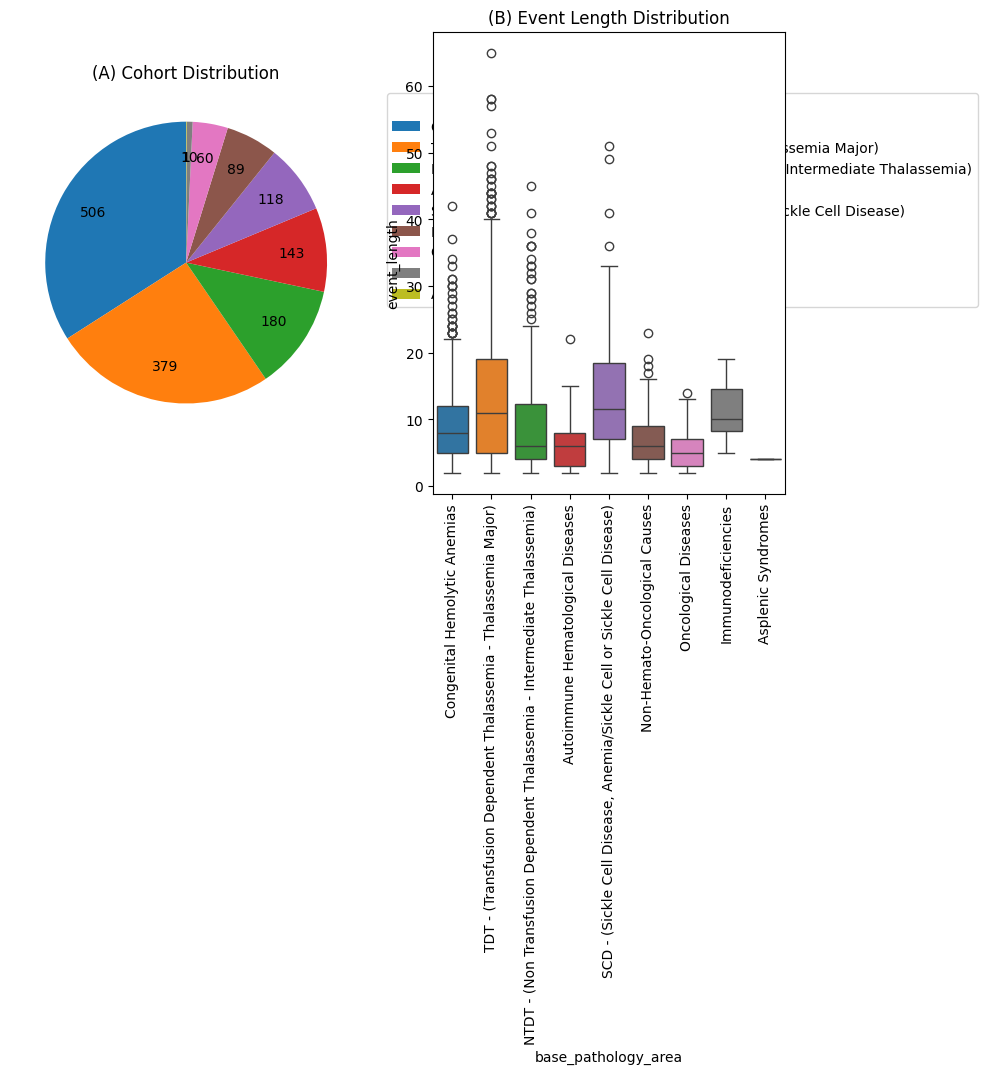

In [9]:
from scripts.utils import group_events_by_visit
# get sequence of event names
event_sequences = { id: [(" ".join([event[field] if isinstance(event[field], str) else "NONE" for field in args.evfields]), event[date_field]) for event in events if event[type_field] not in args.remove_events] for (id,events) in args.dataset[[events_field]].to_dict()[events_field].items()} 
event_sequences_type = { id: [(" ".join([event[field] if isinstance(event[field], str) else "NONE" for field in args.evfields]), event[date_field], event[type_field]) for event in events if event[type_field] not in args.remove_events] for (id,events) in args.dataset[[events_field]].to_dict()[events_field].items()} 
visit_sequences = group_events_by_visit(event_sequences)
args.dataset['events'] = args.dataset.apply(lambda row: event_sequences[row.name], axis=1)
print(f"n.{len(event_sequences)} Patients")
if "base_pathology_area" in args.dataset.columns:
    from scripts.utils import plot_group_distribution_with_event_boxplot
    plot_group_distribution_with_event_boxplot(args.dataset, groupby=args.pathology_field)#, label_desc=args.pathologies)

In [10]:
event_sequences = { id: events for (id,events) in event_sequences.items() if len(events) > 0 } 
args.selected_patient_ids = np.array(list(event_sequences.keys()))

### count event by type and cardinality

In [11]:
if False:
    cnt_df = count_events_by_type(event_sequences_type)
    cnt_df

In [12]:
count_events_by_type(event_sequences_type)

,cardinality,n. instances,set
type,,,
surgical_operation,14,1561,"{Transplantation of kidney, open approach, Tra..."
therapy,39,4998,"{Introduction of supplement agent, Introductio..."
vaccination,9,6548,"{Meningococcal conjugate vaccine, serogroups A..."
infection,71,555,"{Otitis media/externa, Influenza due to identi..."
platelet_change,1,1216,{NONE}
comorbidity,241,830,"{Optic neuritis; Optic neuritis, unspecified, ..."


### save sequences

In [13]:
if args.save_events:
      import pickle
      with open(f'data/{dataset}_{len(args.selected_patient_ids)}_{"-".join(evfields)}_events.txt','wb') as f:
            pickle.dump(event_sequences, f)
      with open(f'data/{dataset}_{len(args.selected_patient_ids)}_{"-".join(evfields)}_visits.txt','wb') as f:
            pickle.dump(visit_sequences, f)

## Get static variables

In [14]:
if len(args.static_vars) > 0:
    mapper = {'pediatric': 0, 'adolescent' : 1, 'adult': 2, 'ND' : -1, 'young': 0, 'mature' : 1, 'elder': 2, 'geriatric': 3}
    X_static = args.dataset.loc[args.selected_patient_ids][args.static_vars].copy()
    X_static.replace(mapper, inplace=True)
    cnames = list(X_static.select_dtypes(include=['object']).columns)
    for col in cnames:
        X_static[col], _ = pd.factorize(X_static[col])
else:
    X_static = pd.DataFrame(index=args.selected_patient_ids)
X_static

,gender,age_group,base_pathology_area
id,,,
1,0,0,0
2,1,0,1
3,0,0,1
4,1,0,1
5,0,0,2
...,...,...,...
1948,1,0,1
1949,1,0,1
1950,1,2,1


## Get targets

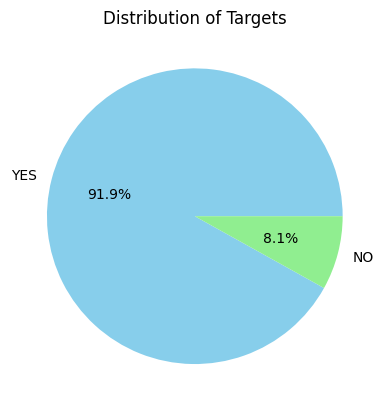

In [15]:
import matplotlib.pyplot as plt
target_df = args.dataset[args.target_var].copy()
target_df.replace({"n/a": "YES", np.nan: "YES"}, inplace=True)
counts = target_df.value_counts()
counts.plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'lightgreen'])
plt.title('Distribution of Targets')
plt.ylabel('')
target_df.replace({"YES": 0, "NO": 1}, inplace=True)
target_df.to_csv(f"data/{dataset}_targets.csv")
plt.show()

In [16]:
target_df.value_counts(dropna=False)

is_alive?
0    1366
1     120
Name: count, dtype: int64

In [15]:
from scripts.configure import configure
embedder_configs = configure(event_sequences, visit_sequences, event_sequences_type, target_df.to_dict(), X_static, args)

#Create empty dataframe for results collections
cols = ["AUC mean","AUC std","F1 mean","F1 std","Prec mean","Prec std","Recall mean","Recall std","MCC mean","MCC std","Acc mean","Acc std","CM"]
dtypes = {"AUC mean": "float64", "AUC std": "float64","F1 mean": "float64","F1 std": "float64","Prec mean": "float64","Prec std": "float64","Recall mean": "float64","Recall std": "float64","MCC mean": "float64","MCC std": "float64","Acc mean": "float64","Acc std": "float64", "CM": "string", "Brier": "float64"}

# Pre-allocate empty DataFrame with correct dtypes
results_df = pd.DataFrame(
    {c: pd.Series(dtype=dt) for c, dt in dtypes.items()},
    columns=cols
)

In [16]:
if False:
    from scripts.cv_folding import lgbm_cv
    set_seed(args.random_state)
    results_tmp, model, train_df, test_df, y_train, y_test= lgbm_cv(embedder_configs, target_df, args.selected_patient_ids,
                                                                        methods=['STATIC', 'CEHRBERT'], threshold=thresh)

## Validation (Iterated 5-fold)

In [17]:
import pickle
if args.iterated_cv:
    from scripts.cv_folding import lgbm_cv_iter
    metrics = ["AUC","F1","Prec","Recall","MCC","Acc","Brier","CM"]
    args.methods = [['STATIC'],
                    ['STATIC', 'BiPadLSTM'], 
                    ['STATIC', 'M2V'],
                    ['STATIC', 'Dipole'],
                    ['STATIC', 'CEHRBERT'],
                    ['STATIC', 'DOME'],
                    ['STATIC', 'GRU'],#['STATIC', 'GRU-D']
                    ]
    prob_pred = {"+".join(m): [] for m in args.methods}
    prob_true = {"+".join(m): [] for m in args.methods}
    all_runs = {"+".join(m): ([], []) for m in args.methods}
    res = {metric: {"+".join(m): [] for m in args.methods} for metric in metrics}
    for i in range(args.iter):
        for m in args.methods:
            set_seed(args.random_state+i)
            results_tmp, model, _,_,_,_, results = lgbm_cv_iter(embedder_configs, target_df, args.selected_patient_ids, 
                                                                methods=m, threshold=thresh, random_state=args.random_state+i, 
                                                                return_metrics=True)
            prob_pred["+".join(m)] += list(results['calibration_prob_pred'])
            prob_true["+".join(m)] += list(results['calibration_prob_true'])
            all_runs["+".join(m)] = (all_runs["+".join(m)][0] + list(results['y_true_oof']),
                                     all_runs["+".join(m)][1] +  list(results['y_prob_oof']))
            with open(f"{args.results_dir}/results_{dataset}_{'_'.join(m)}_ITER{args.iter}.pkl", 'wb') as f:
                pickle.dump(results, f)
            for metric in res.keys():
                print("+".join(m), metric)
                res[metric]["+".join(m)] += [results[metric].tolist()] if metric == "CM" else [results[metric]] if metric == "Brier" else results[metric]
            results_df = pd.concat([results_df, results_tmp],axis=0)
    for metric in res.keys():
        pd.DataFrame(res[metric]).to_csv(f"{args.results_dir}/resdata_{metric}_{dataset}_ITER{args.iter}.csv")
    results_df.to_csv(f"{args.results_dir}/results_{dataset}_ITER{args.iter}.csv")
    results_df


STATIC+GRU AUC
STATIC+GRU F1
STATIC+GRU Prec
STATIC+GRU Recall
STATIC+GRU MCC
STATIC+GRU Acc
STATIC+GRU Brier
STATIC+GRU CM


## Plot calibaration curves

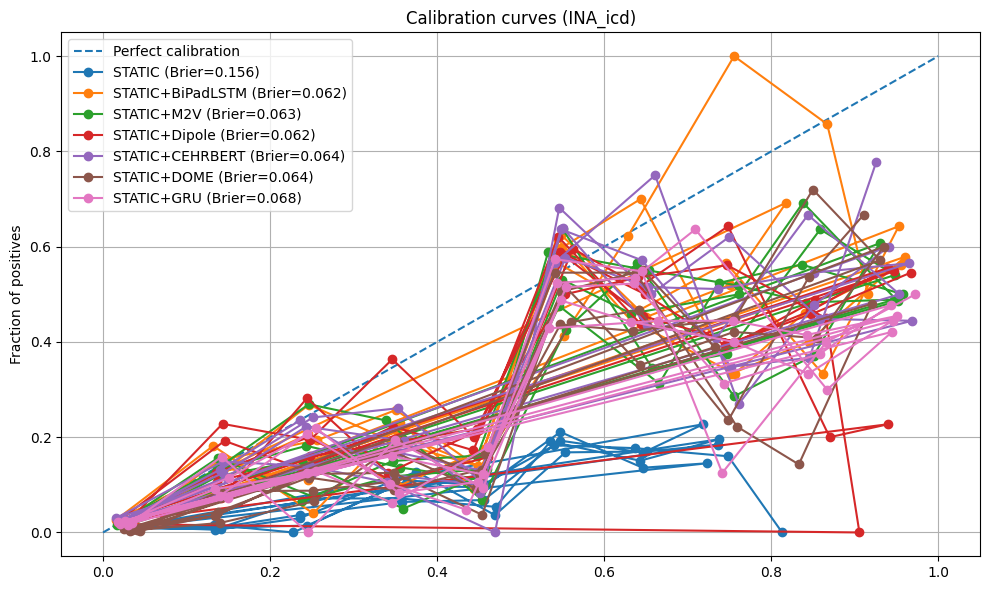

In [18]:
from scripts.plotting import plot_calibration

fig = plot_calibration(prob_pred, prob_true,all_runs,title=f"Calibration curves ({dataset})")
fig.savefig(f"figures/caliba_curve_{dataset}_ITER{args.iter}.png")


## Validation (5-fold)

In [19]:
if not args.iterated_cv:
    from scripts.cv_folding import lgbm_cv
    args.methods = [#['STATIC'],
                    #['STATIC', 'BiPadLSTM'], 
                    #['STATIC', 'M2V'],
                    #['STATIC', 'Dipole'],
                    #['STATIC', 'DOME']
                    #['STATIC', 'GRU'],['STATIC', 'GRU-D'],
                    ['STATIC', 'CEHRBERT']]
    for m in args.methods:
        set_seed(args.random_state)
        results_tmp, model, train_df, test_df, y_train, y_test= lgbm_cv(embedder_configs, target_df, args.selected_patient_ids,
                                                                        methods=m, threshold=thresh)
        results_df = pd.concat([results_df, results_tmp],axis=0)
    results_df

# END 

# End-TO-END CLASSIFIFICATION

In [20]:
if False:
    from scripts.cv_folding import e2e_cv
    args.methods = ['M2V']
    for m in args.methods:
        set_seed(args.random_state)
        results_tmp, y_train, y_test= e2e_cv(embedder_configs, target_df, args.selected_patient_ids,
                                                                        method=m)
        results_df = pd.concat([results_df, results_tmp],axis=0)
    results_df